<a href="https://colab.research.google.com/github/ArchanaGajendra/Data-science-projects/blob/main/mlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix


In [ ]:
data = pd.read_csv('/content/drive/MyDrive/DATASETS/IMDB Dataset.csv', names=['Message', 'Label'])
print("The Total instances in the Dataset: ", data.shape[0])

The Total instances in the Dataset:  50001


In [ ]:
data.head()

,Message,Label
0,review,sentiment
1,One of the other reviewers has mentioned that ...,positive
2,A wonderful little production. <br /><br />The...,positive
3,I thought this was a wonderful way to spend ti...,positive
4,Basically there's a family where a little boy ...,negative


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50001 entries, 0 to 50000
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Message  50001 non-null  object
 1   Label    50001 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [ ]:
print('Target Category wise Number of Records')
data.groupby('Label').size()

Target Category wise Number of Records


,0
Label,
negative,25000
positive,25000
sentiment,1


In [ ]:
data['class'] = data.Label.map({'positive': 1, 'negative': 0})
data = data.dropna(subset= ['class'])
data.head()

,Message,Label,class
1,One of the other reviewers has mentioned that ...,positive,1.0
2,A wonderful little production. <br /><br />The...,positive,1.0
3,I thought this was a wonderful way to spend ti...,positive,1.0
4,Basically there's a family where a little boy ...,negative,0.0
5,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1.0


In [ ]:
#### Splitting Train and Test Dataset
X = data["Message"]
y = data["class"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.25, random_state = 0, stratify = y)

In [ ]:
#### Vectorization
count_vect = CountVectorizer()
X_train_dims = count_vect.fit_transform(X_train)
X_test_dims = count_vect.transform(X_test)
### avoid doin creating the dense dataframe 'df' initially..let the proceed with model building using x_train_dims and x_test_dims directly

In [ ]:
#### Model Building
# Model Building and Fitting

mlp = MLPClassifier(solver='lbfgs', alpha=1e-5,hidden_layer_sizes=(5, 2), random_state=1)
mlp.fit(X_train_dims, y_train)


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:545: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


MLPClassifier(alpha=1e-05, hidden_layer_sizes=(5, 2), random_state=1,
              solver='lbfgs')

In [ ]:
#### Prediction of Test Dataset

y_pred = mlp.predict(X_test_dims) # Print the predicted values
print("Prediction for test set:",y_pred)


Prediction for test set: [1. 0. 0. ... 1. 1. 1.]


In [ ]:
# Actual value and the predicted value
test = pd.DataFrame({'Actual value': y_test, 'Predicted value': y_pred})
test

,Actual value,Predicted value
3578,1.0,1.0
22648,0.0,0.0
10101,0.0,0.0
18117,0.0,0.0
6311,1.0,1.0
...,...,...
3447,0.0,1.0
35071,0.0,0.0
34357,1.0,1.0
22725,1.0,1.0


              precision    recall  f1-score   support

         0.0       0.88      0.88      0.88      6250
         1.0       0.88      0.88      0.88      6250

    accuracy                           0.88     12500
   macro avg       0.88      0.88      0.88     12500
weighted avg       0.88      0.88      0.88     12500



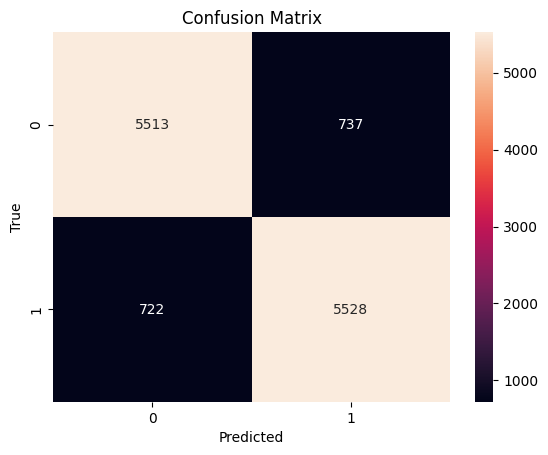

In [ ]:
#### Evaluation of the Model

matrix = confusion_matrix(y_test, y_pred)
sb.heatmap(matrix, annot=True, fmt="d")
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
print(classification_report(y_test, y_pred))


In [ ]:
00#### Prediction for New Unseen Statement

test_stmt = [input("Enter any statement to predict :")]
test_dims = count_vect.transform(test_stmt)
pred = mlp.predict(test_dims)

if pred == 1:
 print("Statement is Positive")
else:
 print("Statement is Negative")


Enter any statement to predict :wonderful
Statement is Positive
